In [406]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
torch.set_printoptions(sci_mode=False)
import torch.optim as optim

In [450]:
# Generate input data
xs = torch.linspace(-5, 5, 100).view(-1, 1)  # Shape [100, 1]
F = lambda xs: torch.sqrt(25 - xs**2)  # Target values, same shape
ys = F(xs)

In [472]:
model = nn.Sequential(
    nn.Linear(1, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)


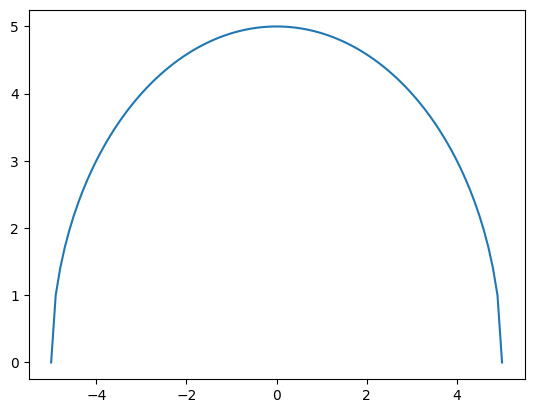

In [473]:
plt.plot(xs, ys)

In [474]:


# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 10000
for epoch in range(epochs):
    model.train()

    # Forward pass
    outputs = model(xs)
    loss = criterion(outputs, ys)

    # Backpropagation and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print progress
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [100/10000], Loss: 0.0499
Epoch [200/10000], Loss: 0.0186
Epoch [300/10000], Loss: 0.0118
Epoch [400/10000], Loss: 0.0082
Epoch [500/10000], Loss: 0.0055
Epoch [600/10000], Loss: 0.0043
Epoch [700/10000], Loss: 0.0037
Epoch [800/10000], Loss: 0.0049
Epoch [900/10000], Loss: 0.0019
Epoch [1000/10000], Loss: 0.0017
Epoch [1100/10000], Loss: 0.0030
Epoch [1200/10000], Loss: 0.0022
Epoch [1300/10000], Loss: 0.0016
Epoch [1400/10000], Loss: 0.0024
Epoch [1500/10000], Loss: 0.0024
Epoch [1600/10000], Loss: 0.0007
Epoch [1700/10000], Loss: 0.0073
Epoch [1800/10000], Loss: 0.0084
Epoch [1900/10000], Loss: 0.0008
Epoch [2000/10000], Loss: 0.0006
Epoch [2100/10000], Loss: 0.0016
Epoch [2200/10000], Loss: 0.0004
Epoch [2300/10000], Loss: 0.0006
Epoch [2400/10000], Loss: 0.0005
Epoch [2500/10000], Loss: 0.0048
Epoch [2600/10000], Loss: 0.0014
Epoch [2700/10000], Loss: 0.0007
Epoch [2800/10000], Loss: 0.0003
Epoch [2900/10000], Loss: 0.0008
Epoch [3000/10000], Loss: 0.0002
Epoch [3100/10000],

In [475]:
tx = torch.linspace(0, 4, 100)
TX= tx.view(-1, 1)

In [476]:
TY = model(TX)

In [477]:
txi = TX.view(-1)

In [478]:
tyi = TY.view(-1)

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

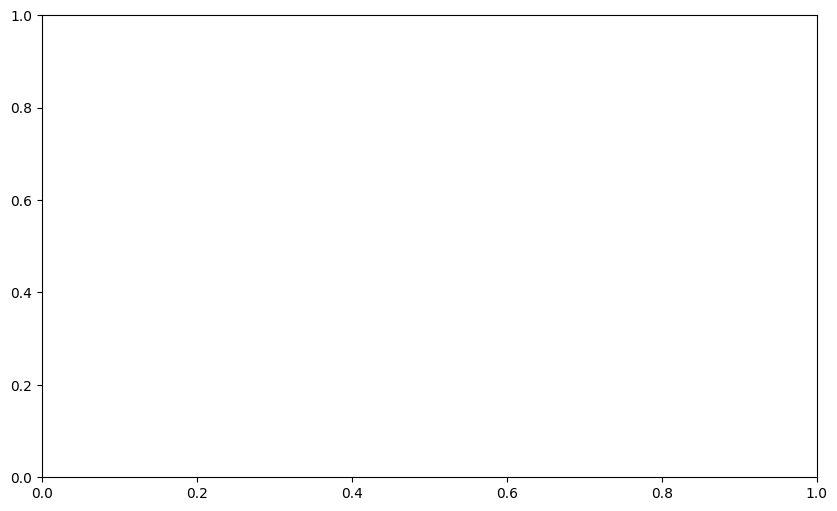

In [497]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.array(txi), np.array(tyi))
ax.plot(np.arrtxi, F(txi))

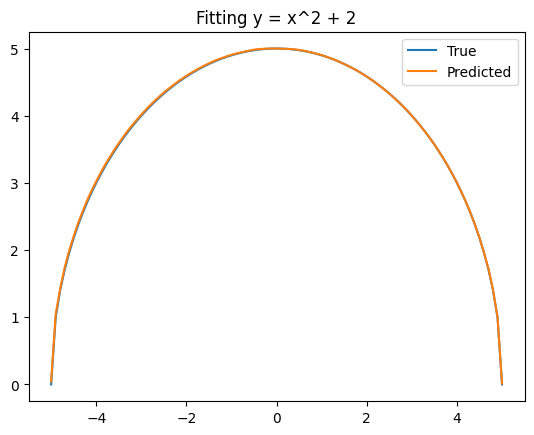

In [471]:
import matplotlib.pyplot as plt

model.eval()
predicted = model(xs).detach()

plt.plot(xs.numpy(), ys.numpy(), label='True')
plt.plot(xs.numpy(), predicted.numpy(), label='Predicted')
plt.legend()
plt.title("Fitting y = x^2 + 2")
plt.show()